<a href="https://colab.research.google.com/github/faizakhoeruzzahra/Tugas-Visualisasi-Data/blob/main/2304020187_TUGAS_VISUALISASI_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statistics import mean
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from sklearn import preprocessing
from scipy.stats import pearsonr

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving EvaluasiTingkatStress.xlsx to EvaluasiTingkatStress.xlsx


In [ ]:
# membaca file excel yang sudah diupload
df = pd.read_excel(list(uploaded.keys())[0])

In [ ]:
# melihat nama kolom (biar memastikan nama kolomnya benar)
print(df.columns)

Index(['Timestamp', 'Nama atau Inisial', 'Usia', 'Jenis Kelamin', 'Status',
       'Bekerja', 'Jam Tidur Perhari', 'Kesibukan Perhari',
       'Frequency of Anger', 'Lack of Control', 'Anxiety and Stress',
       'Self-Efficacy', 'Perceived Control', 'Perceived Overwhelm',
       'Feeling of Mastery', 'Cumulative Difficulty', 'Stress Level'],
      dtype='object')


In [ ]:
# mengubah kategori stress level menjadi angka
mapping_stress = {'Low Stress': 0, 'Moderate Stress': 1, 'High Stress': 2}
df['Stress Level'] = df['Stress Level'].map(mapping_stress)

In [ ]:
# cek hasilnya
df.head()

,Timestamp,Nama atau Inisial,Usia,Jenis Kelamin,Status,Bekerja,Jam Tidur Perhari,Kesibukan Perhari,Frequency of Anger,Lack of Control,Anxiety and Stress,Self-Efficacy,Perceived Control,Perceived Overwhelm,Feeling of Mastery,Cumulative Difficulty,Stress Level
0,2023-10-07 16:07:39.724,RN,19,Perempuan,Mahasiswa,Tidak,1,8,4,3,5,2,3,5,1,5,2
1,2023-09-29 09:55:57.361,H,20,Laki-laki,Mahasiswa,Ya,3,15,5,5,5,4,3,2,1,2,1
2,2023-10-06 13:38:13.700,Suci,22,Perempuan,Mahasiswa,Tidak,3,8,5,5,5,2,2,5,1,5,2
3,2023-10-06 14:19:37.871,odre,18,Perempuan,Mahasiswa,Ya,3,10,4,3,5,2,2,4,1,4,2
4,2023-10-06 22:32:05.257,AF,18,Perempuan,Mahasiswa,Tidak,3,4,3,5,5,2,1,5,1,5,2


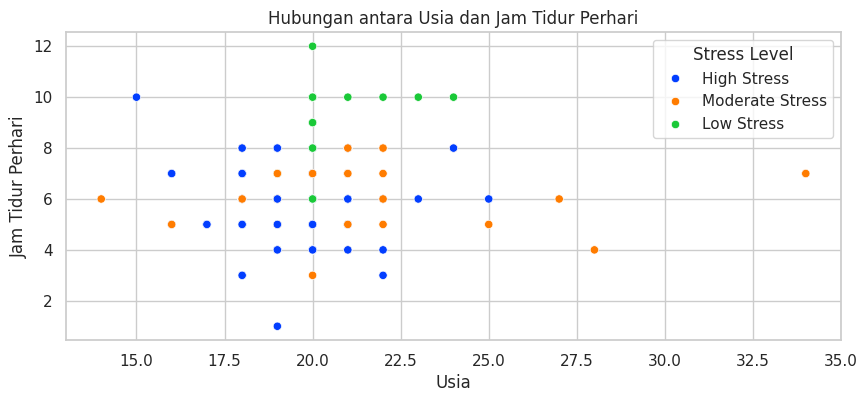

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asumsikan df adalah DataFrame Anda
# Membuat scatter plot antara 'Usia' dan 'Jam Tidur Perhari' dengan warna berdasarkan 'Stress Level'
plt.figure(figsize=(10, 4))
sns.scatterplot(x='Usia', y='Jam Tidur Perhari', data=df, hue='Stress Level', palette='bright')
plt.title('Hubungan antara Usia dan Jam Tidur Perhari')
plt.xlabel('Usia')
plt.ylabel('Jam Tidur Perhari')
plt.show()

Grafik scatter plot menunjukkan hubungan antara usia dan jam tidur per hari dengan warna yang merepresentasikan tingkat stres (stress level). Berdasarkan persebaran titik pada grafik, tidak terlihat pola hubungan yang kuat antara usia dan jam tidur karena data tersebar pada berbagai usia. Grafik ini menunjukkan variasi durasi tidur pada setiap tingkat stres serta membantu menggambarkan distribusi data responden.

In [ ]:
# Mengganti nilai 0, 1, 2 dengan label yang sesuai
df['Stress Level'].replace({0: 'Low Stress', 1: 'Moderate Stress', 2: 'High Stress'}, inplace = True)
df['Jenis Kelamin'].replace({0: 'Laki-laki', 1: 'Perempuan'}, inplace = True)
df['Status'].replace({0:'Pelajar',1:'Mahasiswa',2:'Lainnya'}, inplace=True)
df['Bekerja'].replace({0:'Tidak',1:'Ya'}, inplace=True)

/tmp/ipykernel_4378/2361377751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stress Level', y='Usia', data=df, palette="viridis")


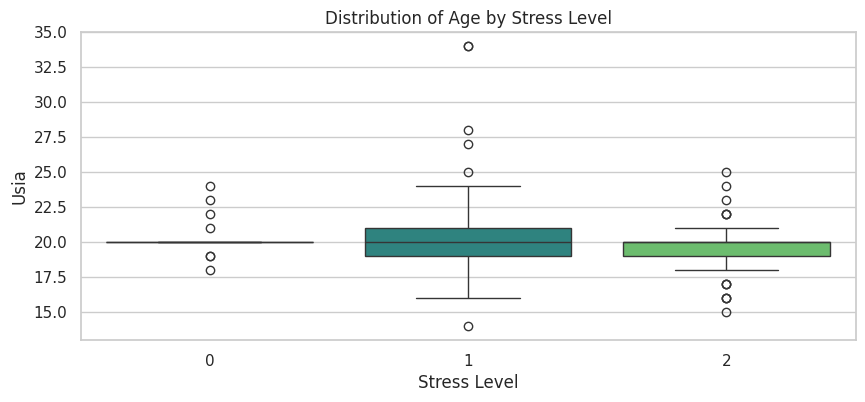

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribusi Usia berdasarkan Stress Level
sns.set(style="whitegrid")
plt.figure(figsize=(10, 4))
sns.boxplot(x='Stress Level', y='Usia', data=df, palette="viridis")
plt.title('Distribution of Age by Stress Level')
plt.show()

Grafik boxplot ini menampilkan distribusi usia berdasarkan tingkat stres. Boxplot menunjukkan bahwa distribusi usia pada setiap tingkat stres relatif mirip, dengan sebagian besar responden berada pada usia sekitar 18–22 tahun. Meskipun terdapat beberapa nilai pencilan pada usia yang lebih tinggi, secara umum tidak terlihat perbedaan yang signifikan dalam distribusi usia antar tingkat stres.

/tmp/ipykernel_4378/1217667788.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Stress Level', data=df, palette='bright')


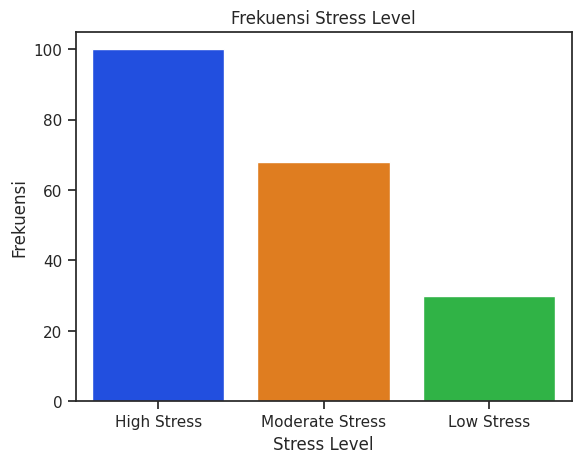

In [ ]:
import seaborn as sns

# Bar Plot untuk Stress Level
sns.countplot(x='Stress Level', data=df, palette='bright')
plt.title('Frekuensi Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frekuensi')
plt.show()

Bar plot menunjukkan bahwa kategori High Stress memiliki jumlah responden paling banyak, diikuti oleh Moderate Stress, dan Low Stress yang memiliki jumlah paling sedikit. Bar plot menunjukkan bahwa sebagian besar responden dalam data berada pada tingkat stres yang relatif tinggi dibandingkan dengan tingkat stres lainnya. Hal ini membantu menggambarkan perbandingan jumlah responden pada setiap kategori tingkat stres secara jelas.

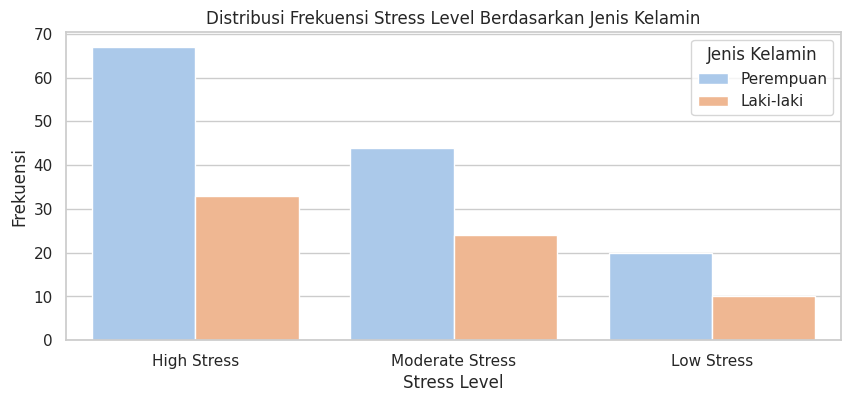

In [ ]:
# Menghitung frekuensi masing-masing kategori
count_stress = df['Stress Level'].value_counts()

# Membuat barplot dengan Seaborn
plt.figure(figsize=(10, 4))
sns.countplot(x='Stress Level', hue='Jenis Kelamin', data=df, palette='pastel')

# Menambahkan label dan judul
plt.xlabel('Stress Level')
plt.ylabel('Frekuensi')
plt.title('Distribusi Frekuensi Stress Level Berdasarkan Jenis Kelamin')

# Menampilkan plot
plt.show()

Bar plot menunjukkan bahwa perempuan memiliki jumlah responden lebih banyak pada setiap tingkat stres dibandingkan laki-laki. Selain itu, High Stress merupakan kategori yang paling dominan pada kedua jenis kelamin.

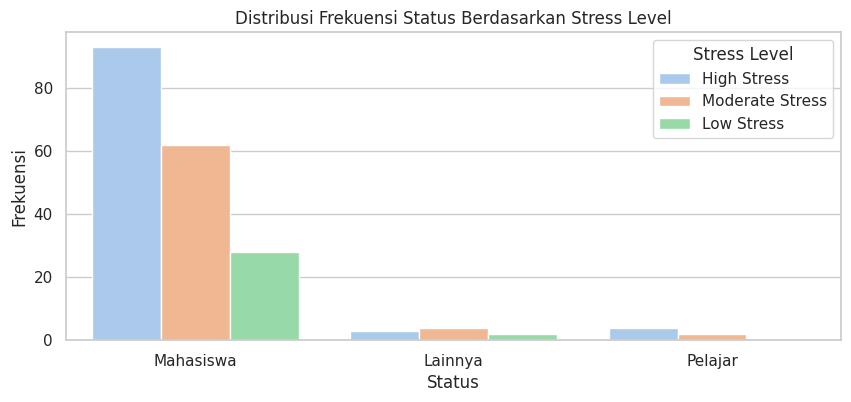

In [ ]:
# Bar Plot untuk Variabel Kategorikal
plt.figure(figsize=(10, 4))
sns.countplot(x='Status', hue='Stress Level', data=df, palette='pastel')
# Menambahkan label dan judul
plt.xlabel('Status')
plt.ylabel('Frekuensi')
plt.title('Distribusi Frekuensi Status Berdasarkan Stress Level')
plt.show()

Bar plot menunjukkan bahwa mahasiswa memiliki jumlah responden lebih banyak pada setiap tingkat stres dibandingkan pelajar dan status lainnya. Selain itu, High Stress merupakan kategori yang paling tinggi pada mahasiswa.

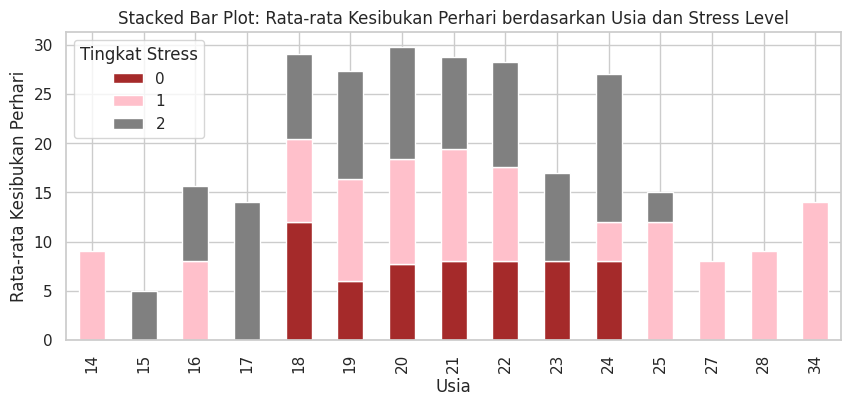

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Membuat DataFrame contoh
pivot_df = df.pivot_table(index='Usia', columns='Stress Level', values='Kesibukan Perhari', aggfunc='mean')

# Membuat bar plot bertingkat
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 4),
              color=['brown','pink','grey'])

plt.title('Stacked Bar Plot: Rata-rata Kesibukan Perhari berdasarkan Usia dan Stress Level')
plt.xlabel('Usia')
plt.ylabel('Rata-rata Kesibukan Perhari')
plt.legend(title='Tingkat Stress', loc='upper left')
plt.show()

Berdasarkan grafik stacked bar plot, terlihat bahwa rata-rata kesibukan per hari berbeda pada setiap usia dan tingkat stres. Secara umum, mahasiswa dengan tingkat stres yang lebih tinggi cenderung memiliki tingkat kesibukan yang lebih besar, terutama pada rentang usia sekitar 18–22 tahun. Hal ini menunjukkan bahwa kesibukan harian dapat berkaitan dengan tingkat stres yang dialami mahasiswa.

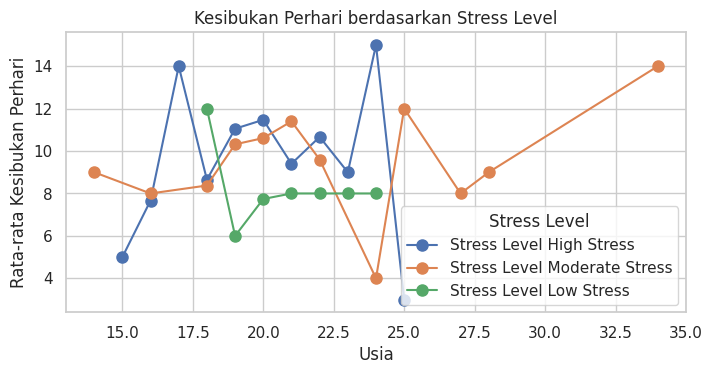

In [ ]:
import matplotlib.pyplot as plt

# Mengatur ukuran keseluruhan figur
plt.figure(figsize=(8, 8))

# Subplot untuk 'Kesibukan Perhari'
plt.subplot(2, 1, 1)  # 2 baris, 1 kolom, posisi pertama
for tingkat_stress in df['Stress Level'].unique():
    sub_data = df[df['Stress Level'] == tingkat_stress]
    plt.plot(sub_data.groupby('Usia')['Kesibukan Perhari'].mean(), marker='o', linestyle='-', markersize=8, label=f'Stress Level {tingkat_stress}')

plt.title('Kesibukan Perhari berdasarkan Stress Level')
plt.xlabel('Usia')
plt.ylabel('Rata-rata Kesibukan Perhari')
plt.legend(title='Stress Level')
plt.grid(True)


Diagram garis menunjukkan bahwa kesibukan per hari memiliki hubungan dengan tingkat stres. Semakin tinggi kesibukan, tingkat stres cenderung lebih tinggi.

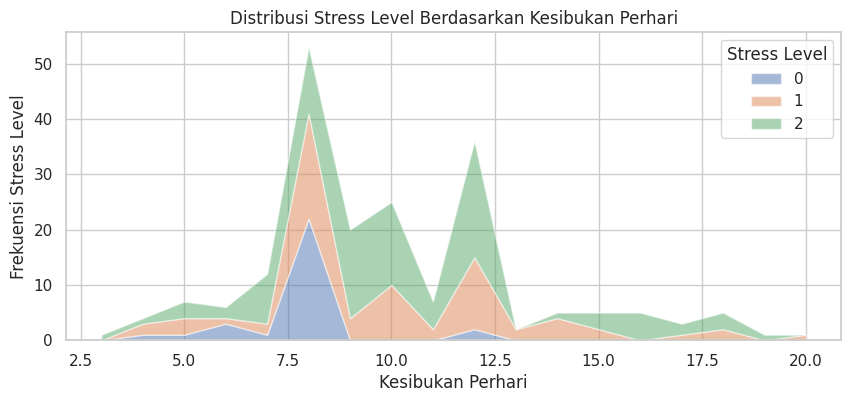

In [ ]:
# Menghitung frekuensi stress level per interval Kesibukan Perhari
stress_counts = df.groupby('Kesibukan Perhari')['Stress Level'].value_counts().unstack().fillna(0)

# Membuat area chart
plt.figure(figsize=(10, 4))
plt.stackplot(stress_counts.index, stress_counts.transpose(), labels=stress_counts.columns, alpha=0.5)

# Menambahkan label dan judul
plt.xlabel('Kesibukan Perhari')
plt.ylabel('Frekuensi Stress Level')
plt.title('Distribusi Stress Level Berdasarkan Kesibukan Perhari')
plt.legend(title='Stress Level')

# Menampilkan plot
plt.show()

Grafik menunjukkan distribusi tingkat stres pada berbagai tingkat kesibukan per hari terlihat bahwa pada beberapa tingkat kesibukan jumlah individu dengan tingkat stres lebih dominan dibandingkan yang lain.

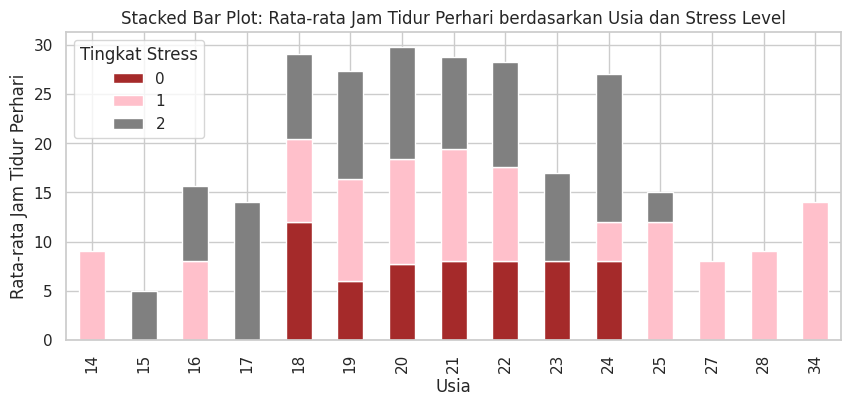

In [ ]:
# Bar plot untuk Jam Tidur Perhari
pivot_df = df.pivot_table(index='Usia', columns='Stress Level', values='Kesibukan Perhari', aggfunc='mean')

pivot_df.plot(kind='bar', stacked=True, figsize=(10, 4),
              color=['brown','pink','grey'])

plt.title('Stacked Bar Plot: Rata-rata Jam Tidur Perhari berdasarkan Usia dan Stress Level')
plt.xlabel('Usia')
plt.ylabel('Rata-rata Jam Tidur Perhari')
plt.legend(title='Tingkat Stress', loc='upper left')
plt.show()

Stacked bar plot menunjukkan perbandingan rata-rata jam tidur per hari pada berbagai usia dengan tingkat stres yang berbeda. Terlihat bahwa jumlah jam tidur bervariasi pada setiap usia dan tingkat stres.

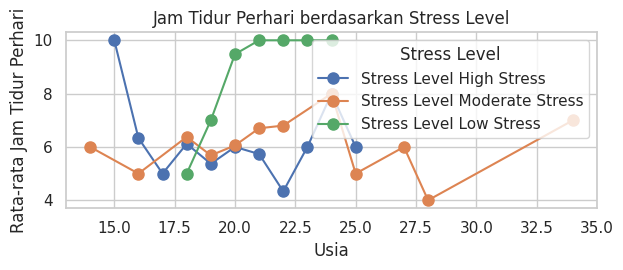

In [ ]:
# Subplot untuk 'Jam Tidur Perhari'
plt.subplot(2, 1, 2)  # 2 baris, 1 kolom, posisi kedua
for tingkat_stress in df['Stress Level'].unique():
    sub_data = df[df['Stress Level'] == tingkat_stress]
    plt.plot(sub_data.groupby('Usia')['Jam Tidur Perhari'].mean(), marker='o', linestyle='-', markersize=8, label=f'Stress Level {tingkat_stress}')

plt.title('Jam Tidur Perhari berdasarkan Stress Level')
plt.xlabel('Usia')
plt.ylabel('Rata-rata Jam Tidur Perhari')
plt.legend(title='Stress Level')
plt.grid(True)

# Menyesuaikan layout
plt.tight_layout()
plt.show()

Diagram garis menunjukkan bahwa rata-rata jam tidur per hari berbeda pada setiap tingkat stres. Individu dengan stres rendah cenderung memiliki jam tidur yang lebih tinggi dibandingkan dengan stres sedang atau tinggi.

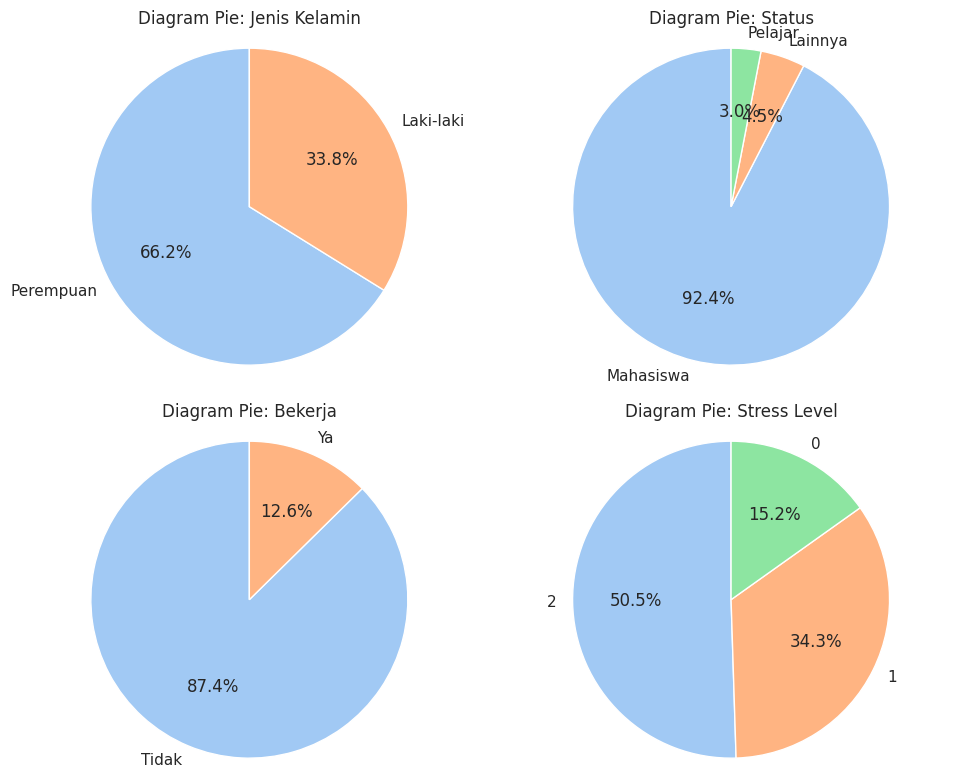

In [ ]:
# Variabel input yang akan divisualisasikan
vars_to_plot = ['Jenis Kelamin','Status','Bekerja','Stress Level']
# Menghitung jumlah variabel input
num_vars = len(vars_to_plot)

# Menentukan jumlah maksimum kolom (width) per baris
max_columns = 2

# Menghitung jumlah baris yang diperlukan
num_rows = (num_vars + max_columns - 1) // max_columns

# Membuat satu gambar dengan subplot sesuai dengan jumlah baris dan kolom
fig, axes = plt.subplots(num_rows, max_columns, figsize=(10, 4 * num_rows))
fig.subplots_adjust(hspace=0.5)

for i, var in enumerate(vars_to_plot):
    row = i // max_columns
    col = i % max_columns

    if num_vars % max_columns != 0 and i == num_vars - 1:
        ax = axes[row, 0]
    else:
        ax = axes[row, col]
# Menghitung jumlah data untuk masing-masing kategori
    category_counts = df[var].value_counts()

    # Mengambil label kategori
    categories = category_counts.index

    # Mengambil jumlah data untuk setiap kategori
    counts = category_counts.values

    # Membuat diagram pie dengan warna yang berbeda
    colors = sns.color_palette('pastel', len(categories))
    ax.pie(counts, labels=categories, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.axis('equal')  # Agar diagram pie menjadi lingkaran

    ax.set_title(f'Diagram Pie: {var}')

# Menyembunyikan subplot kosong jika ada
if num_vars % max_columns != 0:
    axes[num_rows - 1, -1].axis('off')

# Mengatur tata letak subplot
plt.tight_layout()
plt.show()

Pie chart menunjukan bahwa hasil data didominasi oleh mahasiswa perempuan yang tidak bekerja, dan sebagian besar dari mereka mengalami tingkat stres pada level sedang.